In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [11]:
image_path = "./assets/tray7.jpg"

In [12]:
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Nie można znaleźć pliku: {image_path}")

# Kopia obrazu dla rysowania i konwersja do RGB 
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Konwersja do skali szarości i rozmycie w celu redukcji szumów
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (7, 7), 1.5)

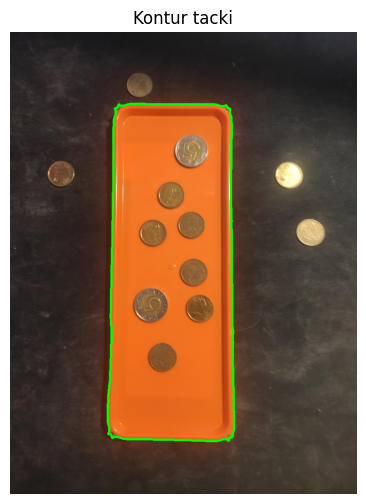

In [13]:
#WYZNACZANIE KONTURU TACKI
#Zastosowanie detekcji krawędzi Canny
edges = cv2.Canny(blurred, 50, 145)

# Operacje morfologiczne,
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

# Znalezienie konturów
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_with_tray_contour = img_rgb.copy()

# Najwięszky kontur to tacka
if contours:
    tray_contour = max(contours, key=cv2.contourArea)
    cv2.drawContours(img_with_tray_contour, [tray_contour], -1, (0, 255, 0), 3) 
else:
    raise ValueError("Nie znaleziono konturu tacki")

plt.figure(figsize=(6, 6))
plt.imshow(img_with_tray_contour)
plt.title("Kontur tacki")
plt.axis("off")
plt.show()

In [14]:
#Obaszar tacki
tray_area = cv2.contourArea(tray_contour)
print(f"Obszar tacki: {tray_area:.0f} pikseli kwadratowych")

Obszar tacki: 188802 pikseli kwadratowych


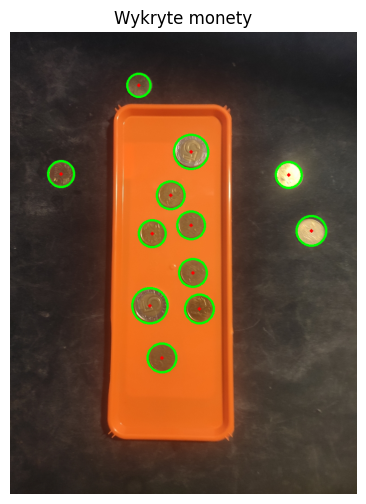

In [15]:
#HoughCircles
img_with_coin_countours = img_rgb.copy()

circles = cv2.HoughCircles(
    blurred, 
    cv2.HOUGH_GRADIENT, 
    dp=1.2, 
    minDist=40,       # Minimalny dystans pomiędzy środkami monet
    param1=50,        # Czułość 
    param2=50,        # Próg dla akceptacji
    minRadius=20,     # Minimalny promień monety
    maxRadius=80      # Maksymalny promień monety
)

if circles is not None:
    circles = np.uint16(np.around(circles))
    
    for i in circles[0, :]: #type: ignore
        center = (i[0], i[1]) # Współrzędne środka (x, y)
        radius = i[2]         # Promień okręgu
        
        # Argumenty: obraz, środek, promień, kolor, grubość linii
        cv2.circle(img_with_coin_countours, center, radius, (0, 255, 0), 3)
        
        #Środek monety
        cv2.circle(img_with_coin_countours, center, 2, (255, 0, 0), 3)

else:
    print("Nie wykryto żadnych monet przy obecnych parametrach!")

plt.figure(figsize=(6, 6))
plt.imshow(img_with_coin_countours)
plt.title("Wykryte monety")
plt.axis("off") 
plt.show()

In [16]:
large_on_tray = 0
small_on_tray = 0
large_off_tray = 0
small_off_tray = 0

# Konfiguracja nominałów (przykład: duża=5zł, mała=1zł) - do podmiany po analizie zdjęć!
VAL_LARGE = 5.0 
VAL_SMALL = 0.05 

THRESHOLD_RADIUS = 33

------------------------------
PODSUMOWANIE MONET:
Na tacce   -> Duże: 2, Małe: 6
Poza tacką -> Duże: 0, Małe: 4
------------------------------
PODSUMOWANIE KWOT:
Kwota na tacce   : 10.3 PLN
Kwota poza tacką : 0.2 PLN
------------------------------


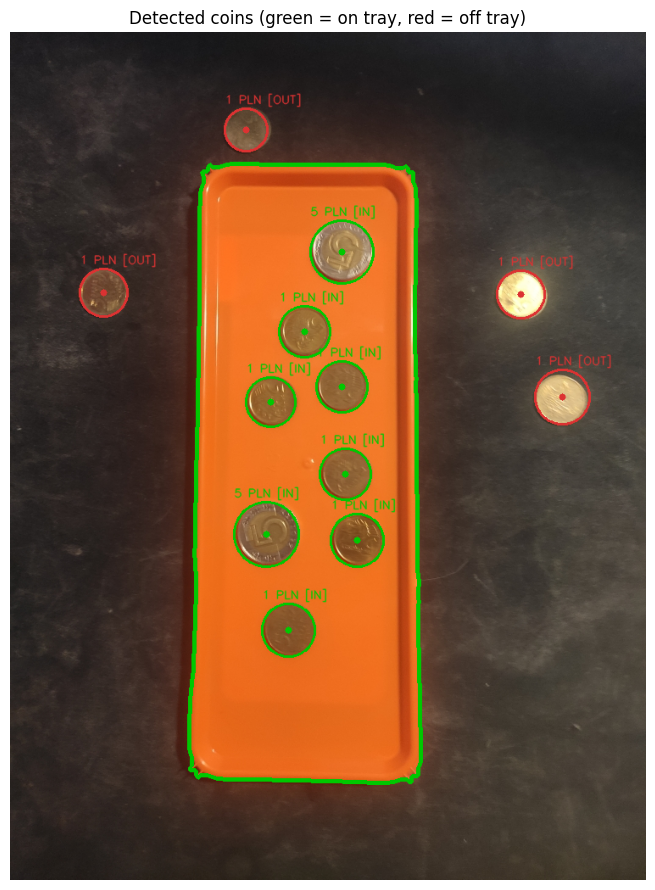

In [17]:
img_for_counting = img_rgb.copy()
cv2.drawContours(img_for_counting, [tray_contour], -1, (0, 200, 0), 3)

if circles is not None:
    for i in circles[0, :]: #type: ignore
        center = (int(i[0]), int(i[1]))
        radius = int(i[2])

        is_inside = cv2.pointPolygonTest(tray_contour, center, measureDist=False) >= 0
        is_large = radius > THRESHOLD_RADIUS

        if is_inside:
            if is_large: large_on_tray += 1
            else: small_on_tray += 1
        else:
            if is_large: large_off_tray += 1
            else: small_off_tray += 1

        color = (0, 200, 0) if is_inside else (220, 50, 50)
        label = ("5 PLN" if is_large else "5 gr") + (" [IN]" if is_inside else " [OUT]")
        cv2.circle(img_for_counting, center, radius, color, 2)
        cv2.circle(img_for_counting, center, 4, color, -1)
        cv2.putText(img_for_counting, label, (center[0] - radius, center[1] - radius - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)

    money_on_tray = (large_on_tray * VAL_LARGE) + (small_on_tray * VAL_SMALL)
    money_off_tray = (large_off_tray * VAL_LARGE) + (small_off_tray * VAL_SMALL)

    print("-" * 30)
    print("PODSUMOWANIE MONET:")
    print(f"Na tacce   -> Duże: {large_on_tray}, Małe: {small_on_tray}")
    print(f"Poza tacką -> Duże: {large_off_tray}, Małe: {small_off_tray}")
    print("-" * 30)
    print("PODSUMOWANIE KWOT:")
    print(f"Kwota na tacce   : {money_on_tray} PLN")
    print(f"Kwota poza tacką : {money_off_tray} PLN")
    print("-" * 30)

    plt.figure(figsize=(7, 9))
    plt.imshow(img_for_counting)
    plt.title("Detected coins (green = on tray, red = off tray)")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("assets/detected_example.png", dpi=150, bbox_inches="tight")
    plt.show()

else:
    print("Zmienna circles jest pusta. Uruchom najpierw komórkę z HoughCircles.")
